In [3]:
# Import Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from housing_env import HousingEnv

# ensure plots render inline
%matplotlib inline


### Define Simulation Parameters

In [4]:
# environment parameters
num_inspectors = 150
inspection_rate = 4
years = 1  # one year of data
max_active_reports = 600

# storage for history
history = []

# Check date range in the data
df_check = pd.read_csv("data/311_fullproc.csv")
df_check['Created Date'] = pd.to_datetime(df_check['Created Date'])
min_date = df_check['Created Date'].min()
max_date = df_check['Created Date'].max()
print(f"\nData Date Range:")
print(f"  Earliest: {min_date.date()}")
print(f"  Latest: {max_date.date()}")
print(f"  Total days: {(max_date - min_date).days}")

# Determine training and test periods
# Example: Train on first 5 years, test on year 6
train_start = min_date.date()
train_end = train_start + datetime.timedelta(days=365*5)
test_start = train_end + datetime.timedelta(days=1)
test_end = test_start + datetime.timedelta(days=365)

print(f"\nProposed Split:")
print(f"  Training: {train_start} to {train_end} (5 years)")
print(f"  Testing: {test_start} to {test_end} (1 year)")


Data Date Range:
  Earliest: 2020-01-01
  Latest: 2026-02-22
  Total days: 2244

Proposed Split:
  Training: 2020-01-01 to 2024-12-30 (5 years)
  Testing: 2024-12-31 to 2025-12-31 (1 year)



## Train RL Agents

This section trains three agents: a random baseline, a TD-learning agent, and a Deep Q-Network.

In [12]:
# Install and Import Stable Baselines3

import subprocess
import sys
from gymnasium import spaces, Wrapper
from stable_baselines3 import DQN
import gymnasium as gym

# Wrapper to flatten Dict observation Space (keeps compatibility with SB3)
class FlattenDictObsWrapper(Wrapper):
    """Convert Dict observation to flattened Box observation for Stable Baselines3."""
    def __init__(self, env):
        super().__init__(env)
        reports_shape = env.observation_space["reports"].shape
        mask_shape = env.observation_space["mask"].shape
        inspectors_shape = env.observation_space["inspectors"].shape if isinstance(env.observation_space["inspectors"], spaces.Box) else (1,)
        timestep_shape = env.observation_space["timestep"].shape if isinstance(env.observation_space["timestep"], spaces.Box) else (1,)
        
        flat_size = (reports_shape[0] * reports_shape[1] + 
                     mask_shape[0] + 
                     (inspectors_shape[0] if isinstance(inspectors_shape, tuple) else 1) +
                     (timestep_shape[0] if isinstance(timestep_shape, tuple) else 1))
        
        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(flat_size,),
            dtype=np.float32
        )
    
    def reset(self, **kwargs):
        # Allow seed/options to be passed through; fallback for older envs
        kwargs.pop('seed', None)
        kwargs.pop('options', None)
        obs, info = self.env.reset(**kwargs)
        return self._flatten_obs(obs), info
    
    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        return self._flatten_obs(obs), reward, terminated, truncated, info
    
    def _flatten_obs(self, obs):
        # Flatten each component properly
        reports_flat = obs["reports"].flatten().astype(np.float32)
        mask_flat = obs["mask"].astype(np.float32)
        inspectors_flat = np.atleast_1d(np.asarray(obs["inspectors"], dtype=np.float32)).flatten()
        timestep_flat = np.atleast_1d(np.asarray(obs["timestep"], dtype=np.float32)).flatten()
        
        return np.concatenate([reports_flat, mask_flat, inspectors_flat, timestep_flat])

# Simple Random Agent for baseline (works with Discrete hierarchical action space)
class RandomAgent:
    """Baseline agent that takes random actions."""
    def __init__(self, env):
        self.env = env
        self.action_space = env.action_space
    
    def select_action(self, obs):
        return int(self.action_space.sample())

print("Environment wrappers and agent classes ready.")


Environment wrappers and agent classes ready.


In [13]:
# Import stable-baselines3
from stable_baselines3 import DQN
from gymnasium.wrappers import FlattenObservation

print("\n" + "="*60)
print("HIERARCHICAL DQN AGENT")
print("="*60)

# Create environment for training (5 years starting from earliest date)
print("\nCreating training environment (5 years: 2020-2024)...")
env_dqn_train = HousingEnv(
    num_inspectors=num_inspectors,
    inspection_rate=inspection_rate,
    years=4,  # Train for 4 years
    max_active_reports=max_active_reports,
    hierarchical=True,
    data_path="data/311_preproc.csv",
    start_date_str=str(min_date.date()),  # Start from earliest date in dataset
)

# Flatten the observation space for DQN
env_dqn_train = FlattenObservation(env_dqn_train)

print(f"  Action space: {env_dqn_train.action_space}")
print(f"  Observation space: {env_dqn_train.observation_space}")

# Create DQN model
print("\nCreating DQN model...")
dqn_model = DQN(
    "MlpPolicy",
    env_dqn_train,
    learning_rate=1e-4,
    buffer_size=50000,
    learning_starts=1000,
    batch_size=32,
    gamma=0.99,
    tau=1.0,
    target_update_interval=1000,
    exploration_fraction=0.1,
    exploration_initial_eps=1.0,
    exploration_final_eps=0.05,
    verbose=0,
)

# Train for five years of timesteps
timesteps_for_5_years = int(365 * 5 * inspection_rate)
print(f"\nTraining DQN for {timesteps_for_5_years} timesteps (5 years)...")
dqn_model.learn(total_timesteps=timesteps_for_5_years, log_interval=500)

print("\n✓ DQN Training complete!")



HIERARCHICAL DQN AGENT

Creating training environment (5 years: 2020-2024)...
  Action space: Discrete(90000)
  Observation space: Box(0.0, 1.0, (6751,), float32)

Creating DQN model...

Training DQN for 7300 timesteps (5 years)...


/opt/miniconda3/lib/python3.13/site-packages/stable_baselines3/common/buffers.py:242: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 2.70GB > 1.06GB
  warnings.warn(



✓ DQN Training complete!


In [14]:
# Evaluate both agents on fresh 1-year environment (test year)
print("\n" + "="*60)
print(f"TESTING BOTH AGENTS ON FRESH 1-YEAR ENVIRONMENT ({str(test_start)})")
print("="*60)

# Create fresh environment for testing (1 year) - use year after training
timesteps_per_year = int(365 * inspection_rate)

env_test = HousingEnv(
    num_inspectors=num_inspectors,
    inspection_rate=inspection_rate,
    years=1,  # Test year
    max_active_reports=max_active_reports,
    hierarchical=True,
    data_path="data/311_preproc.csv",
    start_date_str=str(test_start),  # Test on year after training
)

env_test_wrapped = FlattenObservation(env_test)

# Test DQN on the test environment
print(f"\nEvaluating trained DQN on test year ({str(test_start)})...")
obs, info = env_test_wrapped.reset()
dqn_rewards = []
dqn_violations = []
dqn_reports_closed = []
dqn_open_reports = 0

for t in range(timesteps_per_year):
    action, _states = dqn_model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env_test_wrapped.step(action)
    
    dqn_rewards.append(reward)
    violations_this_step = sum(1 for det in info.get('inspection_details', []) if det.get('outcome') == 'VIOLATION')
    reports_closed_this_step = len(info.get('inspection_details', []))
    dqn_violations.append(violations_this_step)
    dqn_reports_closed.append(reports_closed_this_step)
    dqn_open_reports = info.get('open_reports', 0)
    
    if (t + 1) % 200 == 0:
        print(f"  Timestep {t+1}/{timesteps_per_year}")
    
    if terminated or truncated:
        break

dqn_total_reward = sum(dqn_rewards)
dqn_total_violations = sum(dqn_violations)
dqn_total_closed = sum(dqn_reports_closed)

print(f"\nDQN Results (test year {str(test_start)}):")
print(f"  Total Reward: {dqn_total_reward:.2f}")
print(f"  Total Violations Fixed: {dqn_total_violations}")
print(f"  Total Reports Closed: {dqn_total_closed}")
print(f"  Final Open Reports: {dqn_open_reports}")
print(f"  Avg Reward per Timestep: {np.mean(dqn_rewards):.4f}")

print(f"\nEvaluating random baseline on same test year ({str(test_start)})...")

env_test_baseline = HousingEnv(
    num_inspectors=num_inspectors,
    inspection_rate=inspection_rate,
    years=1,  # Same test year
    max_active_reports=max_active_reports,
    hierarchical=True,
    data_path="data/311_preproc.csv",
    start_date_str=str(test_start),  # Same test period
)

agent_test = RandomAgent(env_test_baseline)
obs, info = env_test_baseline.reset()
baseline_rewards = []
baseline_violations = []
baseline_reports_closed = []
baseline_open_reports = 0

for t in range(timesteps_per_year):
    action = agent_test.select_action(obs)
    obs, reward, terminated, truncated, info = env_test_baseline.step(action)
    
    baseline_rewards.append(reward)
    violations_this_step = sum(1 for det in info.get('inspection_details', []) if det.get('outcome') == 'VIOLATION')
    reports_closed_this_step = len(info.get('inspection_details', []))
    baseline_violations.append(violations_this_step)
    baseline_reports_closed.append(reports_closed_this_step)
    baseline_open_reports = info.get('open_reports', 0)
    
    if (t + 1) % 200 == 0:
        print(f"  Timestep {t+1}/{timesteps_per_year}")
    
    if terminated or truncated:
        break

baseline_total_reward = sum(baseline_rewards)
baseline_total_violations = sum(baseline_violations)
baseline_total_closed = sum(baseline_reports_closed)

print(f"\nRandom Baseline Results (test year {str(test_start)}):")
print(f"  Total Reward: {baseline_total_reward:.2f}")
print(f"  Total Violations Fixed: {baseline_total_violations}")
print(f"  Total Reports Closed: {baseline_total_closed}")
print(f"  Final Open Reports: {baseline_open_reports}")
print(f"  Avg Reward per Timestep: {np.mean(baseline_rewards):.4f}")


TESTING BOTH AGENTS ON FRESH 1-YEAR ENVIRONMENT (2024-12-31)

Evaluating trained DQN on test year (2024-12-31)...
  Timestep 200/1460

DQN Results (test year 2024-12-31):
  Total Reward: 2209.00
  Total Violations Fixed: 84
  Total Reports Closed: 365
  Final Open Reports: 599
  Avg Reward per Timestep: 6.0521

Evaluating random baseline on same test year (2024-12-31)...
  Timestep 200/1460

Random Baseline Results (test year 2024-12-31):
  Total Reward: 2138.00
  Total Violations Fixed: 80
  Total Reports Closed: 364
  Final Open Reports: 599
  Avg Reward per Timestep: 5.8575



COMPARISON: RANDOM BASELINE vs. HIERARCHICAL DQN (1 Year)


                 Metric Random Baseline Hierarchical DQN
           Total Reward         2138.00          2209.00
 Total Violations Fixed              80               84
   Total Reports Closed             364              365
     Final Open Reports             599              599
Avg Reward per Timestep          5.8575           6.0521

DQN Improvements over Random Baseline:
  Total Reward: +3.3%
  Total Violations Fixed: +5.0%
  Total Reports Closed: +0.3%


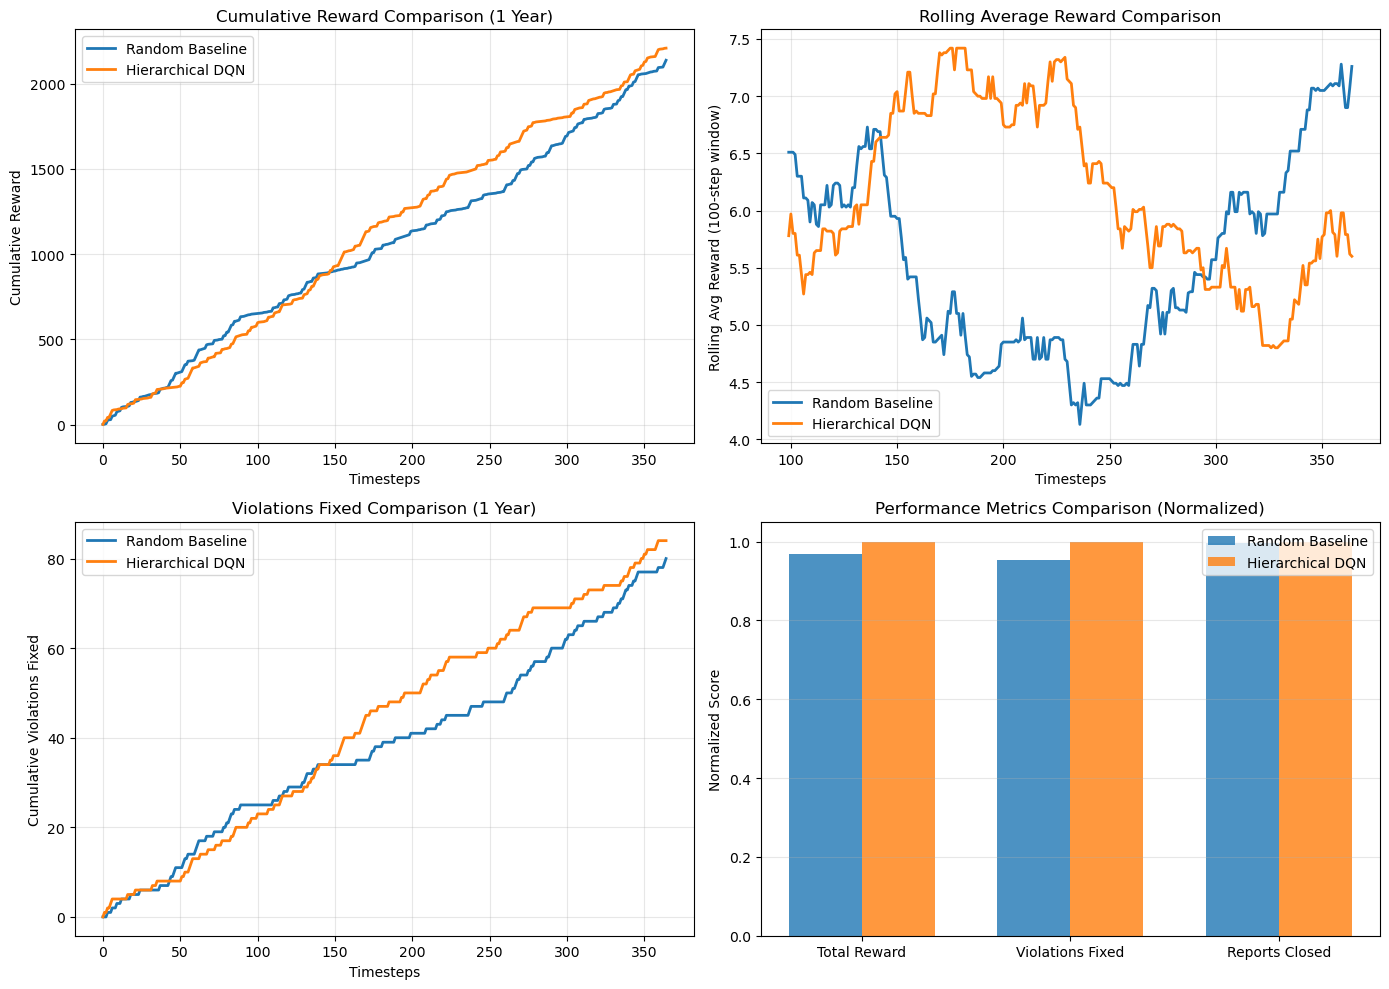

In [15]:
# Comparison Summary
print("\n" + "="*60)
print("COMPARISON: RANDOM BASELINE vs. HIERARCHICAL DQN (1 Year)")
print("="*60)

comparison_data = {
    'Metric': [
        'Total Reward',
        'Total Violations Fixed',
        'Total Reports Closed',
        'Final Open Reports',
        'Avg Reward per Timestep'
    ],
    'Random Baseline': [
        f"{baseline_total_reward:.2f}",
        f"{baseline_total_violations}",
        f"{baseline_total_closed}",
        f"{baseline_open_reports}",
        f"{np.mean(baseline_rewards):.4f}"
    ],
    'Hierarchical DQN': [
        f"{dqn_total_reward:.2f}",
        f"{dqn_total_violations}",
        f"{dqn_total_closed}",
        f"{dqn_open_reports}",
        f"{np.mean(dqn_rewards):.4f}"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n")
print(comparison_df.to_string(index=False))

# Calculate improvements
reward_improvement = ((dqn_total_reward - baseline_total_reward) / abs(baseline_total_reward)) * 100
violations_improvement = ((dqn_total_violations - baseline_total_violations) / max(baseline_total_violations, 1)) * 100
closed_improvement = ((dqn_total_closed - baseline_total_closed) / max(baseline_total_closed, 1)) * 100

print(f"\nDQN Improvements over Random Baseline:")
print(f"  Total Reward: {reward_improvement:+.1f}%")
print(f"  Total Violations Fixed: {violations_improvement:+.1f}%")
print(f"  Total Reports Closed: {closed_improvement:+.1f}%")

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Cumulative Rewards
ax = axes[0, 0]
ax.plot(np.cumsum(baseline_rewards), label='Random Baseline', linewidth=2)
ax.plot(np.cumsum(dqn_rewards), label='Hierarchical DQN', linewidth=2)
ax.set_xlabel('Timesteps')
ax.set_ylabel('Cumulative Reward')
ax.set_title('Cumulative Reward Comparison (1 Year)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Rolling Average Reward (100-timestep window)
ax = axes[0, 1]
window = 100
baseline_rolling = pd.Series(baseline_rewards).rolling(window=window).mean()
dqn_rolling = pd.Series(dqn_rewards).rolling(window=window).mean()
ax.plot(baseline_rolling, label='Random Baseline', linewidth=2)
ax.plot(dqn_rolling, label='Hierarchical DQN', linewidth=2)
ax.set_xlabel('Timesteps')
ax.set_ylabel(f'Rolling Avg Reward ({window}-step window)')
ax.set_title('Rolling Average Reward Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Cumulative Violations Fixed
ax = axes[1, 0]
ax.plot(np.cumsum(baseline_violations), label='Random Baseline', linewidth=2)
ax.plot(np.cumsum(dqn_violations), label='Hierarchical DQN', linewidth=2)
ax.set_xlabel('Timesteps')
ax.set_ylabel('Cumulative Violations Fixed')
ax.set_title('Violations Fixed Comparison (1 Year)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Summary Bar Chart
ax = axes[1, 1]
metrics = ['Total Reward', 'Violations Fixed', 'Reports Closed']
baseline_vals = [baseline_total_reward, baseline_total_violations, baseline_total_closed]
dqn_vals = [dqn_total_reward, dqn_total_violations, dqn_total_closed]

x = np.arange(len(metrics))
width = 0.35

# Normalize for visualization if ranges differ significantly
baseline_norm = [v / max(baseline_vals[i], dqn_vals[i]) if max(baseline_vals[i], dqn_vals[i]) > 0 else 0 for i, v in enumerate(baseline_vals)]
dqn_norm = [v / max(baseline_vals[i], dqn_vals[i]) if max(baseline_vals[i], dqn_vals[i]) > 0 else 0 for i, v in enumerate(dqn_vals)]

ax.bar(x - width/2, baseline_norm, width, label='Random Baseline', alpha=0.8)
ax.bar(x + width/2, dqn_norm, width, label='Hierarchical DQN', alpha=0.8)
ax.set_ylabel('Normalized Score')
ax.set_title('Performance Metrics Comparison (Normalized)')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')


plt.tight_layout()
plt.show()

In [16]:
import os

def save_model_results(
    output_dir="results",
    dqn_rewards=None,
    dqn_violations=None,
    dqn_reports_closed=None,
    baseline_rewards=None,
    baseline_violations=None,
    baseline_reports_closed=None,
):
    """Save per-step DQN and random baseline evaluation data to separate CSVs.

    Each file contains columns:
        step, reward, cumulative_reward,
        violations, cumulative_violations,
        reports_closed, cumulative_reports_closed

    Parameters
    ----------
    output_dir              : Directory to write CSVs into (created if absent).
    dqn_rewards             : Per-step reward list from DQN evaluation.
    dqn_violations          : Per-step violations list from DQN evaluation.
    dqn_reports_closed      : Per-step reports-closed list from DQN evaluation.
    baseline_rewards        : Per-step reward list from random baseline.
    baseline_violations     : Per-step violations list from random baseline.
    baseline_reports_closed : Per-step reports-closed list from random baseline.
    """
    os.makedirs(output_dir, exist_ok=True)

    def _to_df(rewards, violations, reports_closed):
        n = len(rewards)
        return pd.DataFrame({
            "step":                      range(n),
            "reward":                    rewards,
            "cumulative_reward":         list(np.cumsum(rewards)),
            "violations":                violations,
            "cumulative_violations":     list(np.cumsum(violations)),
            "reports_closed":            reports_closed,
            "cumulative_reports_closed": list(np.cumsum(reports_closed)),
        })

    if dqn_rewards is not None:
        path = os.path.join(output_dir, "eval_dqn.csv")
        _to_df(dqn_rewards, dqn_violations or [0]*len(dqn_rewards),
               dqn_reports_closed or [0]*len(dqn_rewards)).to_csv(path, index=False)
        print(f"Saved {path}  ({len(dqn_rewards)} steps)")

    if baseline_rewards is not None:
        path = os.path.join(output_dir, "eval_random.csv")
        _to_df(baseline_rewards, baseline_violations or [0]*len(baseline_rewards),
               baseline_reports_closed or [0]*len(baseline_rewards)).to_csv(path, index=False)
        print(f"Saved {path}  ({len(baseline_rewards)} steps)")


save_model_results(
    output_dir="results",
    dqn_rewards=dqn_rewards,
    dqn_violations=dqn_violations,
    dqn_reports_closed=dqn_reports_closed,
    baseline_rewards=baseline_rewards,
    baseline_violations=baseline_violations,
    baseline_reports_closed=baseline_reports_closed,
)

Saved results/eval_dqn.csv  (365 steps)
Saved results/eval_random.csv  (365 steps)


In [5]:
import glob as _glob
import os

def load_model_results(results_dir="results"):
    """Load per-step evaluation CSVs saved by save_model_results.

    Scans *results_dir* for files matching ``eval_*.csv`` and returns a dict
    keyed by model name (e.g. ``"dqn"``, ``"random"``).  Each value is a dict
    with lists for every tracked metric:
        rewards, cumulative_rewards,
        violations, cumulative_violations,
        reports_closed, cumulative_reports_closed

    Parameters
    ----------
    results_dir : str
        Directory that contains the ``eval_*.csv`` files.

    Returns
    -------
    dict[str, dict[str, list]]
    """
    results = {}
    csv_files = sorted(_glob.glob(os.path.join(results_dir, "eval_*.csv")))

    if not csv_files:
        print(f"No eval_*.csv files found in '{results_dir}/'")
        return results

    for path in csv_files:
        model_name = os.path.splitext(os.path.basename(path))[0].removeprefix("eval_")
        df = pd.read_csv(path)
        results[model_name] = {
            "rewards":                    df["reward"].tolist(),
            "cumulative_rewards":         df["cumulative_reward"].tolist(),
            "violations":                 df["violations"].tolist(),
            "cumulative_violations":      df["cumulative_violations"].tolist(),
            "reports_closed":             df["reports_closed"].tolist(),
            "cumulative_reports_closed":  df["cumulative_reports_closed"].tolist(),
        }
        print(f"Loaded '{model_name}' from {path}  ({len(df)} steps)")

    return results


saved_results = load_model_results("results")


Loaded 'dqn' from results/eval_dqn.csv  (365 steps)
Loaded 'random' from results/eval_random.csv  (365 steps)
Loaded 'reinforce' from results/eval_reinforce.csv  (365 steps)


## REINFORCE with Baseline

Train a policy-gradient agent using the REINFORCE algorithm with a learned value-function baseline.  The policy selects which complaint report to inspect at each step; the baseline V(s) reduces gradient variance by subtracting the estimated return from the actual discounted return G_t.

**Algorithm summary:**
1. Roll out a full episode under policy π  
2. Compute discounted returns G_t = Σ γ^k r_{t+k}  
3. Update policy:  ∇J ≈ Σ_t (G_t − V(s_t)) ∇ log π(a_t | s_t)  
4. Update baseline: minimise MSE( V(s_t), G_t )

In [4]:
from train_reinforce import train_and_evaluate

reinforce_results = train_and_evaluate(
    data_path="data/311_fullproc.csv",
    num_inspectors=num_inspectors,          # 150
    max_active_reports=max_active_reports,  # 600
    inspection_rate=inspection_rate,        # 4
    train_years=5,
    test_years=1,
    train_start_date=str(min_date.date()),  # 2020-01-01
    test_start_date=str(test_start),        # same test period as DQN
    num_episodes=50,
    gamma=0.99,
    lr_policy=1e-4,
    lr_value=1e-3,
    hidden_dim=256,
    normalize_returns=True,
    device="auto",
    seed=42,
    save_path="models/reinforce_baseline.pt",
    plot=False,
    verbose=True,
)

# Extract per-step evaluation data into flat variables matching the DQN section
reinforce_rewards        = reinforce_results["reinforce_eval"]["rewards"]
reinforce_violations     = reinforce_results["reinforce_eval"]["violations"]
reinforce_reports_closed = reinforce_results["reinforce_eval"]["reports_closed"]
reinforce_open_reports   = reinforce_results["reinforce_eval"]["open_reports"]

reinforce_total_reward     = sum(reinforce_rewards)
reinforce_total_violations = sum(reinforce_violations)
reinforce_total_closed     = sum(reinforce_reports_closed)

print(f"\nREINFORCE Results (test year {str(test_start)}):")
print(f"  Total Reward:            {reinforce_total_reward:.2f}")
print(f"  Total Violations Fixed:  {reinforce_total_violations}")
print(f"  Total Reports Closed:    {reinforce_total_closed}")
print(f"  Final Open Reports:      {reinforce_open_reports}")
print(f"  Avg Reward per Timestep: {np.mean(reinforce_rewards):.4f}")

REINFORCE WITH BASELINE — HousingEnv
  Training : 2020-01-01  (5 yr × 50 episodes)
  Testing  : 2024-12-31  (1 yr)
  Device   : cpu
  Obs dim  : 6751  |  Policy outputs: 600  |  Env action space: Discrete(90000)

  Episode    5/50  |  Reward:  43100.0  |  Violations:  475  |  PolicyLoss: 2.9010  |  ValueLoss: 1.1215  |  414s elapsed
  Episode   10/50  |  Reward:  43940.0  |  Violations:  495  |  PolicyLoss: 1.2894  |  ValueLoss: 0.9321  |  839s elapsed
  Episode   15/50  |  Reward:  42640.0  |  Violations:  464  |  PolicyLoss: 0.7487  |  ValueLoss: 0.8812  |  1295s elapsed
  Episode   20/50  |  Reward:  42960.0  |  Violations:  468  |  PolicyLoss: 1.7851  |  ValueLoss: 0.8667  |  1749s elapsed
  Episode   25/50  |  Reward:  41620.0  |  Violations:  434  |  PolicyLoss: 0.3921  |  ValueLoss: 0.7386  |  2236s elapsed
  Episode   30/50  |  Reward:  43580.0  |  Violations:  484  |  PolicyLoss: 0.2887  |  ValueLoss: 0.7530  |  2760s elapsed
  Episode   35/50  |  Reward:  42630.0  |  Violatio

In [5]:
n = len(reinforce_rewards)
pd.DataFrame({
    "step":                      range(n),
    "reward":                    reinforce_rewards,
    "cumulative_reward":         list(np.cumsum(reinforce_rewards)),
    "violations":                reinforce_violations,
    "cumulative_violations":     list(np.cumsum(reinforce_violations)),
    "reports_closed":            reinforce_reports_closed,
    "cumulative_reports_closed": list(np.cumsum(reinforce_reports_closed)),
}).to_csv("results/eval_reinforce.csv", index=False)

print(f"Saved results/eval_reinforce.csv  ({n} steps)")


Saved results/eval_reinforce.csv  (365 steps)


Loaded 'dqn' from results/eval_dqn.csv  (365 steps)
Loaded 'random' from results/eval_random.csv  (365 steps)
Loaded 'reinforce' from results/eval_reinforce.csv  (365 steps)

COMPARISON: RANDOM BASELINE vs. DQN vs. REINFORCE (1 Year)
                 Metric Random Baseline Hierarchical DQN REINFORCE
           Total Reward         2138.00          2209.00   8910.00
 Total Violations Fixed              80               84       102
   Total Reports Closed             364              365       364
Avg Reward per Timestep          5.8575           6.0521   24.4110

Improvements over Random Baseline:
  DQN       — Reward: +3.3%  |  Violations: +5.0%  |  Reports Closed: +0.3%
  REINFORCE — Reward: +316.7%  |  Violations: +27.5%  |  Reports Closed: +0.0%


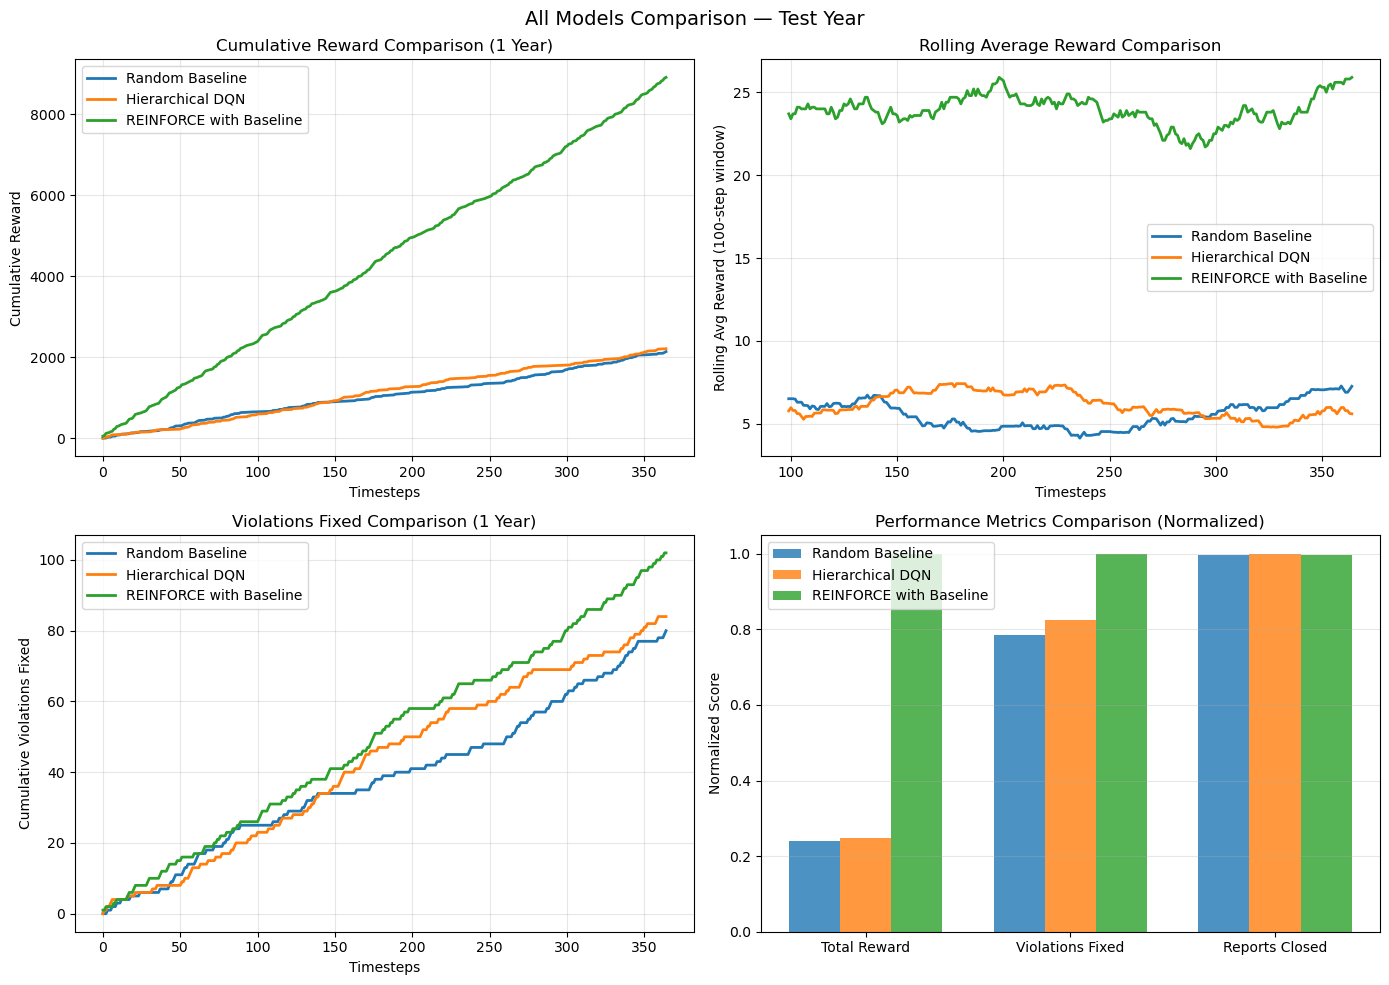

Plot saved to model-comparison.png


In [6]:
# Reload all three model results from CSVs (works even if training cells weren't re-run)
saved_results = load_model_results("results")

def _extract(results, key):
    r = results[key]
    return {
        "rewards":        r["rewards"],
        "violations":     r["violations"],
        "reports_closed": r["reports_closed"],
        "total_reward":   r["cumulative_rewards"][-1],
        "total_violations": r["cumulative_violations"][-1],
        "total_closed":   r["cumulative_reports_closed"][-1],
    }

b = _extract(saved_results, "random")
d = _extract(saved_results, "dqn")
rf = _extract(saved_results, "reinforce")

baseline_rewards         = b["rewards"]
baseline_violations      = b["violations"]
baseline_reports_closed  = b["reports_closed"]
baseline_total_reward    = b["total_reward"]
baseline_total_violations = b["total_violations"]
baseline_total_closed    = b["total_closed"]

dqn_rewards              = d["rewards"]
dqn_violations           = d["violations"]
dqn_reports_closed       = d["reports_closed"]
dqn_total_reward         = d["total_reward"]
dqn_total_violations     = d["total_violations"]
dqn_total_closed         = d["total_closed"]

reinforce_rewards        = rf["rewards"]
reinforce_violations     = rf["violations"]
reinforce_reports_closed = rf["reports_closed"]
reinforce_total_reward   = rf["total_reward"]
reinforce_total_violations = rf["total_violations"]
reinforce_total_closed   = rf["total_closed"]

# All-models comparison summary
print("\n" + "="*65)
print("COMPARISON: RANDOM BASELINE vs. DQN vs. REINFORCE (1 Year)")
print("="*65)

comparison_data_all = {
    'Metric': [
        'Total Reward',
        'Total Violations Fixed',
        'Total Reports Closed',
        'Avg Reward per Timestep'
    ],
    'Random Baseline': [
        f"{baseline_total_reward:.2f}",
        f"{baseline_total_violations}",
        f"{baseline_total_closed}",
        f"{np.mean(baseline_rewards):.4f}"
    ],
    'Hierarchical DQN': [
        f"{dqn_total_reward:.2f}",
        f"{dqn_total_violations}",
        f"{dqn_total_closed}",
        f"{np.mean(dqn_rewards):.4f}"
    ],
    'REINFORCE': [
        f"{reinforce_total_reward:.2f}",
        f"{reinforce_total_violations}",
        f"{reinforce_total_closed}",
        f"{np.mean(reinforce_rewards):.4f}"
    ]
}

comparison_all_df = pd.DataFrame(comparison_data_all)
print(comparison_all_df.to_string(index=False))

# Improvement percentages over random baseline
dqn_reward_pct  = (dqn_total_reward          - baseline_total_reward)      / abs(baseline_total_reward)         * 100
dqn_viol_pct    = (dqn_total_violations       - baseline_total_violations)  / max(baseline_total_violations, 1)  * 100
dqn_closed_pct  = (dqn_total_closed           - baseline_total_closed)      / max(baseline_total_closed, 1)      * 100
rf_reward_pct   = (reinforce_total_reward     - baseline_total_reward)      / abs(baseline_total_reward)         * 100
rf_viol_pct     = (reinforce_total_violations - baseline_total_violations)  / max(baseline_total_violations, 1)  * 100
rf_closed_pct   = (reinforce_total_closed     - baseline_total_closed)      / max(baseline_total_closed, 1)      * 100

print(f"\nImprovements over Random Baseline:")
print(f"  DQN       — Reward: {dqn_reward_pct:+.1f}%  |  Violations: {dqn_viol_pct:+.1f}%  |  Reports Closed: {dqn_closed_pct:+.1f}%")
print(f"  REINFORCE — Reward: {rf_reward_pct:+.1f}%  |  Violations: {rf_viol_pct:+.1f}%  |  Reports Closed: {rf_closed_pct:+.1f}%")

# ── Combined 4-panel visualization ────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"All Models Comparison — Test Year", fontsize=14)

# Panel 1: Cumulative Rewards
ax = axes[0, 0]
ax.plot(np.cumsum(baseline_rewards),  label='Random Baseline',        linewidth=2)
ax.plot(np.cumsum(dqn_rewards),       label='Hierarchical DQN',       linewidth=2)
ax.plot(np.cumsum(reinforce_rewards), label='REINFORCE with Baseline', linewidth=2)
ax.set_xlabel('Timesteps')
ax.set_ylabel('Cumulative Reward')
ax.set_title('Cumulative Reward Comparison (1 Year)')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 2: Rolling Average Reward (100-step window)
ax = axes[0, 1]
window = 100
ax.plot(pd.Series(baseline_rewards).rolling(window=window).mean(),  label='Random Baseline',        linewidth=2)
ax.plot(pd.Series(dqn_rewards).rolling(window=window).mean(),       label='Hierarchical DQN',       linewidth=2)
ax.plot(pd.Series(reinforce_rewards).rolling(window=window).mean(), label='REINFORCE with Baseline', linewidth=2)
ax.set_xlabel('Timesteps')
ax.set_ylabel(f'Rolling Avg Reward ({window}-step window)')
ax.set_title('Rolling Average Reward Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 3: Cumulative Violations Fixed
ax = axes[1, 0]
ax.plot(np.cumsum(baseline_violations),  label='Random Baseline',        linewidth=2)
ax.plot(np.cumsum(dqn_violations),       label='Hierarchical DQN',       linewidth=2)
ax.plot(np.cumsum(reinforce_violations), label='REINFORCE with Baseline', linewidth=2)
ax.set_xlabel('Timesteps')
ax.set_ylabel('Cumulative Violations Fixed')
ax.set_title('Violations Fixed Comparison (1 Year)')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 4: Normalized bar chart (3 models × 3 metrics)
ax = axes[1, 1]
metrics = ['Total Reward', 'Violations Fixed', 'Reports Closed']
b_vals  = [baseline_total_reward,  baseline_total_violations,  baseline_total_closed]
d_vals  = [dqn_total_reward,       dqn_total_violations,       dqn_total_closed]
r_vals  = [reinforce_total_reward, reinforce_total_violations, reinforce_total_closed]
norms   = [max(b_vals[i], d_vals[i], r_vals[i]) or 1 for i in range(3)]
b_norm  = [b_vals[i] / norms[i] for i in range(3)]
d_norm  = [d_vals[i] / norms[i] for i in range(3)]
r_norm  = [r_vals[i] / norms[i] for i in range(3)]

x, w = np.arange(3), 0.25
ax.bar(x - w, b_norm, w, label='Random Baseline',        alpha=0.8)
ax.bar(x,     d_norm, w, label='Hierarchical DQN',       alpha=0.8)
ax.bar(x + w, r_norm, w, label='REINFORCE with Baseline', alpha=0.8)
ax.set_ylabel('Normalized Score')
ax.set_title('Performance Metrics Comparison (Normalized)')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("model-comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to model-comparison.png")